 # **Import Librabies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Cleaned_dataset.csv')


In [ ]:
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


# Selecting Dependent and indipendent Variables

In [ ]:
x = df.drop(['Time_taken_min','Average_Speed_kmph'],axis = 1)
y = df['Time_taken_min']

# Split the data into Traing and Testing data



In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,
                                                 y,
                                                 test_size= 0.2,
                                                 random_state=42)

# Seperation of numerical and categorical columns

In [ ]:
num_cols = x_train.select_dtypes(include = ['int64','float64']).columns
cat_cols = x_train.select_dtypes(include = ['object']).columns

print('Numerical:',list(num_cols))
print('Categorical:',list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


## Encoding

In [ ]:
nominal_col = ['Day_of_Week','Weather','Pickup_Zone','Dropoff_Zone','Vehicle_Type','Cuisine_Type']
ordinal_col = ['Restaurant_Load','Delivery_Distance_Category','Traffic_Level','Delivery_Priority']

In [ ]:
OneHotEncoder(
    handle_unknown='ignore',
    drop='first'
)

OneHotEncoder(drop='first', handle_unknown='ignore')

# Simple Imputer
- Univariate imputer for completing missing values with simple strategies.

Replace missing values using a descriptive statistic (e.g. mean, median, or most frequent) along each column, or using a constant value.

In [ ]:
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [ ]:
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

In [ ]:
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Short", "Medium", "Long"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [ ]:
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [ ]:
model = KNeighborsRegressor(
    n_neighbors=10,
    weights='distance',
    metric='minkowski',
    p=2
)

In [ ]:
pipe=Pipeline(
    [('Preprocessor',preprocessor),
    ('model',model)]
)

In [ ]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=(('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals'],
      dtype='object')),
                                                 ('no...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scalar',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Short',
                                                                                               'Medium',
                                                                                               'Long'],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High',
                                                                                               'Severe'],
                                                                                              ['Normal',
                                                                                               'Priority',
                                                                                               'VIP']]))]),
                                                  ['Restaurant_Load',
                                                   'Delivery_Distance_Category',
                                                   'Traffic_Level',
                                                   'Delivery_Priority'])))),
                ('model',
                 KNeighborsRegressor(n_neighbors=10, weights='distance'))])

In [ ]:
preprocessor.get_feature_names_out()


array(['num__Order_Hour', 'num__Is_Weekend', 'num__Is_Festival',
       'num__Rider_Experience_Years', 'num__Rider_Rating',
       'num__Restaurant_Rating', 'num__Order_Items',
       'num__Preparation_Time_Min', 'num__Road_Distance_km',
       'num__Number_of_Signals', 'nominal__Day_of_Week_Monday',
       'nominal__Day_of_Week_Saturday', 'nominal__Day_of_Week_Sunday',
       'nominal__Day_of_Week_Thursday', 'nominal__Day_of_Week_Tuesday',
       'nominal__Day_of_Week_Wednesday', 'nominal__Weather_Cloudy',
       'nominal__Weather_Fog', 'nominal__Weather_Rain',
       'nominal__Weather_Storm', 'nominal__Pickup_Zone_Commercial',
       'nominal__Pickup_Zone_Industrial',
       'nominal__Pickup_Zone_Residential',
       'nominal__Pickup_Zone_Suburban',
       'nominal__Dropoff_Zone_Commercial',
       'nominal__Dropoff_Zone_Industrial',
       'nominal__Dropoff_Zone_Residential',
       'nominal__Dropoff_Zone_Suburban', 'nominal__Vehicle_Type_Bike',
       'nominal__Vehicle_Type_Electri

In [ ]:
y_pred=pipe.predict(x_test)

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

- I used MAE as the primary evaluation metric because delivery-time error is naturally interpreted in minutes. I also evaluated RMSE to identify the impact of larger errors and R² to assess the model's explanatory performance.

In [ ]:
print(mae)
print(rmse)
print(r2score)

14.049388218226458
20.839981715614712
0.6580905010727784


- MAE = 10.14 minutes: predictions are off by about 10 minutes on average.
- RMSE = 13.57 minutes: larger errors are having a noticeable effect compared with MAE.
- R² = 0.855: the model explains a substantial amount of the variation in delivery times relative to the mean-prediction baseline.

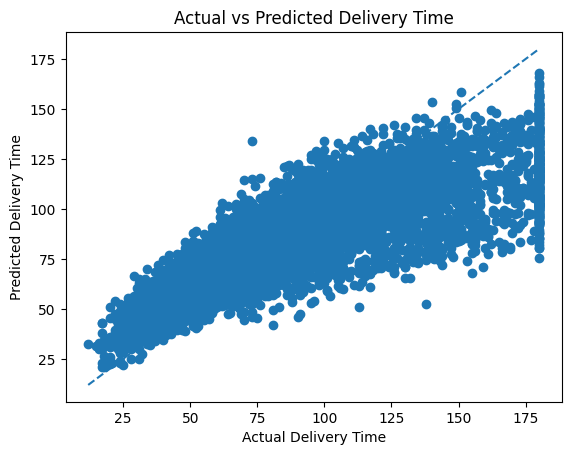

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

- Strong positive relationship.
- Most predictions are close to actual values.
- Some larger errors occur at higher delivery times.

In [ ]:
residual=y_test-y_pred

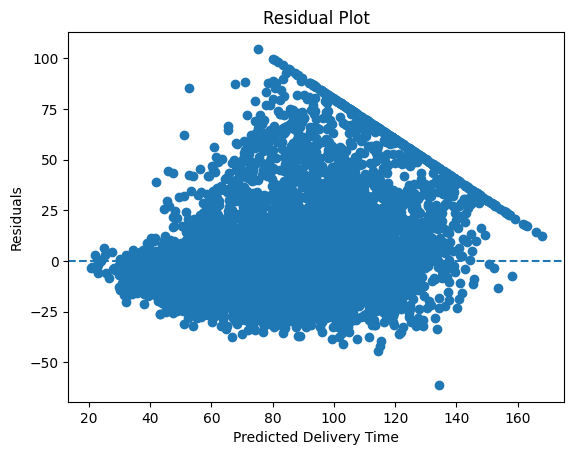

In [ ]:
plt.scatter(y_pred, residual)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

- Residuals are mostly around zero.
- Error spread increases for higher delivery times.
- Some large residuals/outliers are present.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_neighbors': [5, 10, 15, 20],
    'model__weights': ['uniform', 'distance'],
    'model__p': [2]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessor',
                                        ColumnTransformer(transformers=(('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scalar',
                                                                                          StandardScaler())]),
                                                                         Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Sig...
                                                                                                                      'Severe'],
                                                                                                                     ['Normal',
                                                                                                                      'Priority',
                                                                                                                      'VIP']]))]),
                                                                         ['Restaurant_Load',
                                                                          'Delivery_Distance_Category',
                                                                          'Traffic_Level',
                                                                          'Delivery_Priority'])))),
                                       ('model',
                                        KNeighborsRegressor(n_neighbors=10,
                                                            weights='distance'))]),
             n_jobs=-1,
             param_grid={'model__n_neighbors': [5, 10, 15, 20], 'model__p': [2],
                         'model__weights': ['uniform', 'distance']},
             scoring='neg_mean_absolute_error', verbose=1)

In [ ]:

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__n_neighbors': 20, 'model__p': 2, 'model__weights': 'distance'}
Best CV MAE:
13.919184538797094


In [ ]:
best_knn = grid_search.best_estimator_

In [ ]:
y_pred = best_knn.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2score = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2score)

MAE : 13.897054706673204
MSE : 429.65374485771133
RMSE: 20.728090719063136
R²  : 0.6617521063674892


In [ ]:
from sklearn.model_selection  import RandomizedSearchCV

random_=RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

random_.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=(('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scalar',
                                                                                                StandardScaler())]),
                                                                               Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_...
                                                                                                                            'Severe'],
                                                                                                                           ['Normal',
                                                                                                                            'Priority',
                                                                                                                            'VIP']]))]),
                                                                               ['Restaurant_Load',
                                                                                'Delivery_Distance_Category',
                                                                                'Traffic_Level',
                                                                                'Delivery_Priority'])))),
                                             ('model',
                                              KNeighborsRegressor(n_neighbors=10,
                                                                  weights='distance'))]),
                   n_jobs=-1,
                   param_distributions={'model__n_neighbors': [5, 10, 15, 20],
                                        'model__p': [2],
                                        'model__weights': ['uniform',
                                                           'distance']},
                   scoring='neg_mean_absolute_error')

- After hyperparameter tuning, the KNN model improved: MAE and RMSE decreased, while R² increased. This indicates that the tuned model predicts delivery time slightly more accurately than the original model.

In [ ]:
df[['Road_Distance_km',
    'Average_Speed_kmph',
    'Time_taken_min']].corr()

,Road_Distance_km,Average_Speed_kmph,Time_taken_min
Road_Distance_km,1.000000,-0.002157,0.702592
Average_Speed_kmph,-0.002157,1.000000,-0.596058
Time_taken_min,0.702592,-0.596058,1.000000


In [ ]:
df['Estimated_Time_From_Speed'] = (
    df['Road_Distance_km'] / df['Average_Speed_kmph']
) * 60

df[['Estimated_Time_From_Speed',
    'Time_taken_min']].corr()

,Estimated_Time_From_Speed,Time_taken_min
Estimated_Time_From_Speed,1.000000,0.933251
Time_taken_min,0.933251,1.000000


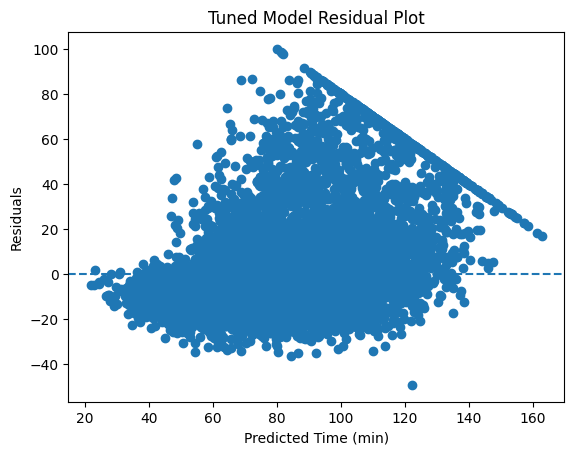

In [ ]:
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Time (min)")
plt.ylabel("Residuals")
plt.title("Tuned Model Residual Plot")
plt.show()

- I got an MAE of 14.05 minutes, so the model predictions are off by around 14 minutes on average.
- The RMSE is 20.84 minutes, which shows that some larger prediction errors are present.
- The R² score is 0.658, so the model is able to explain around 66% of the variation in delivery time.
- From the actual vs predicted graph, I observed a positive relationship between actual and predicted delivery time.
- From the residual plot, most errors are around zero, but the error spread increases for higher delivery times.
- After hyperparameter tuning, the best parameters were K = 20 and distance weighting.
- However, the tuned model gave MAE = 13.90, RMSE = 20.73 and R² = 0.662, so the improvement was very small.
- Overall, KNN is giving moderate performance on my dataset, but it still has difficulty predicting higher delivery times accurately.